In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [39]:
!pip install pymysql

  Using cached pymysql-1.1.2-py3-none-any.whl.metadata (4.3 kB)
Using cached pymysql-1.1.2-py3-none-any.whl (45 kB)


In [14]:
df = pd.read_csv("Aviation_Jan_clean.csv")

In [15]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,01-01-2024,9E,4814,JFK,"New York, NY",New York,...,0,136,122.0,84.0,509,0,0,0,0,0
1,2024,1,1,1,01-01-2024,9E,4815,MSP,"Minneapolis, MN",Minnesota,...,0,130,114.0,88.0,622,0,0,0,0,0
2,2024,1,1,1,01-01-2024,9E,4817,JFK,"New York, NY",New York,...,0,106,90.0,61.0,288,0,0,0,0,0
3,2024,1,1,1,01-01-2024,9E,4817,RIC,"Richmond, VA",Virginia,...,0,111,76.0,51.0,288,0,0,0,0,0
4,2024,1,1,1,01-01-2024,9E,4818,DTW,"Detroit, MI",Michigan,...,0,79,70.0,45.0,237,0,0,0,0,0


In [16]:
df.shape

(547271, 35)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547271 entries, 0 to 547270
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 547271 non-null  int64  
 1   month                547271 non-null  int64  
 2   day_of_month         547271 non-null  int64  
 3   day_of_week          547271 non-null  int64  
 4   fl_date              547271 non-null  object 
 5   op_unique_carrier    547271 non-null  object 
 6   op_carrier_fl_num    547271 non-null  int64  
 7   origin               547271 non-null  object 
 8   origin_city_name     547271 non-null  object 
 9   origin_state_nm      547271 non-null  object 
 10  dest                 547271 non-null  object 
 11  dest_city_name       547271 non-null  object 
 12  dest_state_nm        547271 non-null  object 
 13  crs_dep_time         547271 non-null  int64  
 14  dep_time             527487 non-null  float64
 15  dep_delay        

In [18]:
df.describe()  

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,547271.0,547271.0,547271.000000,547271.000000,547271.000000,547271.000000,527487.000000,527413.000000,527014.000000,527014.000000,...,547271.000000,547271.000000,525370.000000,525370.000000,547271.000000,547271.000000,547271.000000,547271.000000,547271.000000,547271.000000
mean,2024.0,1.0,15.893364,3.802931,2344.884295,1318.558305,1328.487612,15.700680,18.809671,1353.345368,...,0.002763,149.035781,143.394598,116.338489,836.350400,5.685322,1.789534,3.124035,0.041325,6.789291
std,0.0,0.0,8.954236,2.012839,1576.254272,484.686308,498.973771,64.175619,11.389781,499.821673,...,0.052490,73.259120,72.934658,70.804135,593.863755,39.695035,24.735805,15.578983,2.354086,33.386866
min,2024.0,1.0,1.000000,1.000000,1.000000,6.000000,1.000000,-56.000000,1.000000,1.000000,...,0.000000,26.000000,16.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024.0,1.0,8.000000,2.000000,1083.000000,906.000000,914.000000,-5.000000,12.000000,932.000000,...,0.000000,95.000000,90.000000,64.000000,403.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2024.0,1.0,16.000000,4.000000,2069.000000,1315.000000,1325.000000,-2.000000,16.000000,1339.000000,...,0.000000,134.000000,128.000000,100.000000,693.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.0,1.0,24.000000,6.000000,3454.000000,1726.000000,1738.000000,12.000000,21.000000,1753.000000,...,0.000000,180.000000,176.000000,147.000000,1072.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2024.0,1.0,31.000000,7.000000,8819.000000,2359.000000,2400.000000,3125.000000,213.000000,2400.000000,...,1.000000,690.000000,781.000000,723.000000,5095.000000,2972.000000,1804.000000,1431.000000,1005.000000,1565.000000


### Handling Nulls

In [19]:
df.isnull().sum()

year                        0
month                       0
day_of_month                0
day_of_week                 0
fl_date                     0
op_unique_carrier           0
op_carrier_fl_num           0
origin                      0
origin_city_name            0
origin_state_nm             0
dest                        0
dest_city_name              0
dest_state_nm               0
crs_dep_time                0
dep_time                19784
dep_delay               19858
taxi_out                20257
wheels_off              20257
wheels_on               20634
taxi_in                 20634
crs_arr_time                0
arr_time                20633
arr_delay               21901
cancelled                   0
cancellation_code      526882
diverted                    0
crs_elapsed_time            0
actual_elapsed_time     21901
air_time                21901
distance                    0
carrier_delay               0
weather_delay               0
nas_delay                   0
security_d

In [20]:
df.isnull().mean()*100

year                    0.000000
month                   0.000000
day_of_month            0.000000
day_of_week             0.000000
fl_date                 0.000000
op_unique_carrier       0.000000
op_carrier_fl_num       0.000000
origin                  0.000000
origin_city_name        0.000000
origin_state_nm         0.000000
dest                    0.000000
dest_city_name          0.000000
dest_state_nm           0.000000
crs_dep_time            0.000000
dep_time                3.615028
dep_delay               3.628550
taxi_out                3.701457
wheels_off              3.701457
wheels_on               3.770344
taxi_in                 3.770344
crs_arr_time            0.000000
arr_time                3.770161
arr_delay               4.001856
cancelled               0.000000
cancellation_code      96.274423
diverted                0.000000
crs_elapsed_time        0.000000
actual_elapsed_time     4.001856
air_time                4.001856
distance                0.000000
carrier_de

In [21]:
df = df[(df['cancelled'] == 0) & (df['diverted'] == 0)].copy()
df.drop(columns=['cancellation_code'], inplace=True)

In [22]:
df.shape

(525370, 34)

In [23]:
delay_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df[delay_cols] = df[delay_cols].fillna(0)
df.fillna(0, inplace=True)

In [24]:
df.isna().sum()

year                   0
month                  0
day_of_month           0
day_of_week            0
fl_date                0
op_unique_carrier      0
op_carrier_fl_num      0
origin                 0
origin_city_name       0
origin_state_nm        0
dest                   0
dest_city_name         0
dest_state_nm          0
crs_dep_time           0
dep_time               0
dep_delay              0
taxi_out               0
wheels_off             0
wheels_on              0
taxi_in                0
crs_arr_time           0
arr_time               0
arr_delay              0
cancelled              0
diverted               0
crs_elapsed_time       0
actual_elapsed_time    0
air_time               0
distance               0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [25]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,01-01-2024,9E,4814,JFK,"New York, NY",New York,...,0,136,122.0,84.0,509,0,0,0,0,0
1,2024,1,1,1,01-01-2024,9E,4815,MSP,"Minneapolis, MN",Minnesota,...,0,130,114.0,88.0,622,0,0,0,0,0
2,2024,1,1,1,01-01-2024,9E,4817,JFK,"New York, NY",New York,...,0,106,90.0,61.0,288,0,0,0,0,0
3,2024,1,1,1,01-01-2024,9E,4817,RIC,"Richmond, VA",Virginia,...,0,111,76.0,51.0,288,0,0,0,0,0
4,2024,1,1,1,01-01-2024,9E,4818,DTW,"Detroit, MI",Michigan,...,0,79,70.0,45.0,237,0,0,0,0,0


In [27]:
df['total_delay_minutes'] = df[delay_cols].sum(axis=1)
df

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,total_delay_minutes
0,2024,1,1,1,01-01-2024,9E,4814,JFK,"New York, NY",New York,...,136,122.0,84.0,509,0,0,0,0,0,0
1,2024,1,1,1,01-01-2024,9E,4815,MSP,"Minneapolis, MN",Minnesota,...,130,114.0,88.0,622,0,0,0,0,0,0
2,2024,1,1,1,01-01-2024,9E,4817,JFK,"New York, NY",New York,...,106,90.0,61.0,288,0,0,0,0,0,0
3,2024,1,1,1,01-01-2024,9E,4817,RIC,"Richmond, VA",Virginia,...,111,76.0,51.0,288,0,0,0,0,0,0
4,2024,1,1,1,01-01-2024,9E,4818,DTW,"Detroit, MI",Michigan,...,79,70.0,45.0,237,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547266,2024,1,31,3,31-01-2024,YX,5843,LGA,"New York, NY",New York,...,119,106.0,70.0,431,25,0,0,0,13,38
547267,2024,1,31,3,31-01-2024,YX,5844,LGA,"New York, NY",New York,...,90,72.0,51.0,214,0,0,0,0,0,0
547268,2024,1,31,3,31-01-2024,YX,5845,BWI,"Baltimore, MD",Maryland,...,89,68.0,46.0,184,0,0,0,0,0,0
547269,2024,1,31,3,31-01-2024,YX,5845,JFK,"New York, NY",New York,...,73,61.0,40.0,184,0,13,0,0,6,19


In [28]:
df['fl_date'] = pd.to_datetime(df['fl_date'], dayfirst=True)

In [29]:
df.dtypes

year                            int64
month                           int64
day_of_month                    int64
day_of_week                     int64
fl_date                datetime64[ns]
op_unique_carrier              object
op_carrier_fl_num               int64
origin                         object
origin_city_name               object
origin_state_nm                object
dest                           object
dest_city_name                 object
dest_state_nm                  object
crs_dep_time                    int64
dep_time                      float64
dep_delay                     float64
taxi_out                      float64
wheels_off                    float64
wheels_on                     float64
taxi_in                       float64
crs_arr_time                    int64
arr_time                      float64
arr_delay                     float64
cancelled                       int64
diverted                        int64
crs_elapsed_time                int64
actual_elaps

### Handling Outliers

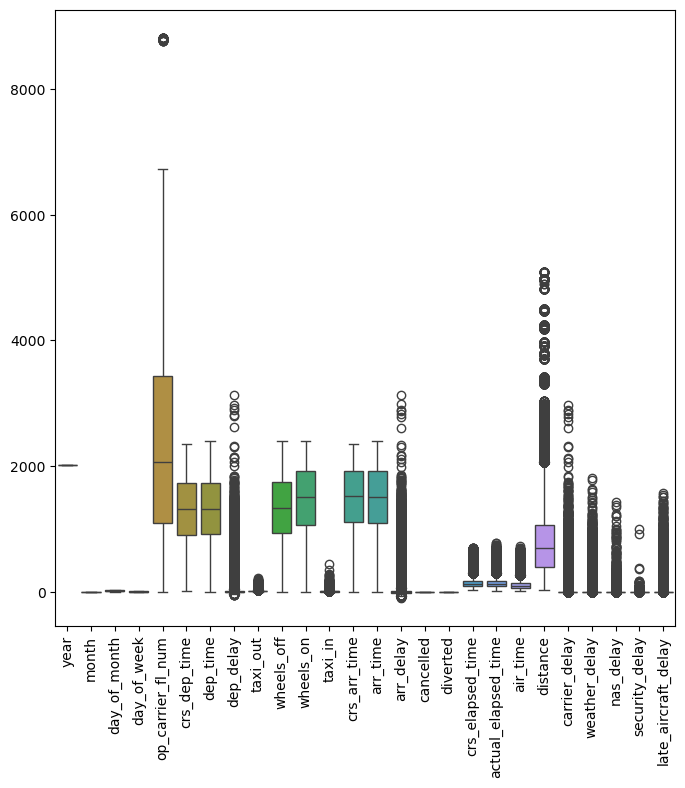

In [40]:
plt.figure(figsize=(8,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [31]:
df.describe()

,year,month,day_of_month,day_of_week,fl_date,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,...,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,total_delay_minutes
count,525370.0,525370.0,525370.000000,525370.000000,525370,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000,...,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000,525370.000000
mean,2024.0,1.0,15.906595,3.813838,2024-01-15 21:45:29.838399232,2341.523088,1318.007800,1328.287447,15.540472,18.796728,...,148.582658,143.394598,116.338489,833.224973,5.922325,1.864134,3.254267,0.043048,7.072315,18.156088
min,2024.0,1.0,1.000000,1.000000,2024-01-01 00:00:00,1.000000,6.000000,1.000000,-56.000000,1.000000,...,26.000000,16.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024.0,1.0,8.000000,2.000000,2024-01-08 00:00:00,1089.000000,907.000000,914.000000,-6.000000,12.000000,...,95.000000,90.000000,64.000000,402.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2024.0,1.0,16.000000,4.000000,2024-01-16 00:00:00,2070.000000,1315.000000,1325.000000,-2.000000,16.000000,...,133.000000,128.000000,100.000000,692.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.0,1.0,24.000000,6.000000,2024-01-24 00:00:00,3441.000000,1725.000000,1738.000000,12.000000,21.000000,...,180.000000,176.000000,147.000000,1069.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2024.0,1.0,31.000000,7.000000,2024-01-31 00:00:00,8819.000000,2359.000000,2400.000000,3125.000000,213.000000,...,690.000000,781.000000,723.000000,5095.000000,2972.000000,1804.000000,1431.000000,1005.000000,1565.000000,3136.000000
std,0.0,0.0,9.065827,2.009303,NaN,1569.261522,484.238732,498.850333,63.711865,11.370345,...,72.892674,72.934658,70.804135,590.696621,40.496643,25.243366,15.887055,2.402637,34.046275,63.544774


In [33]:
Q1 = df['dep_delay'].quantile(0.25)
Q3 = df['dep_delay'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['is_extreme_delay'] = df['dep_delay'] > upper_bound

In [35]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,total_delay_minutes,is_extreme_delay
0,2024,1,1,1,2024-01-01,9E,4814,JFK,"New York, NY",New York,...,122.0,84.0,509,0,0,0,0,0,0,False
1,2024,1,1,1,2024-01-01,9E,4815,MSP,"Minneapolis, MN",Minnesota,...,114.0,88.0,622,0,0,0,0,0,0,False
2,2024,1,1,1,2024-01-01,9E,4817,JFK,"New York, NY",New York,...,90.0,61.0,288,0,0,0,0,0,0,False
3,2024,1,1,1,2024-01-01,9E,4817,RIC,"Richmond, VA",Virginia,...,76.0,51.0,288,0,0,0,0,0,0,False
4,2024,1,1,1,2024-01-01,9E,4818,DTW,"Detroit, MI",Michigan,...,70.0,45.0,237,0,0,0,0,0,0,False


In [ ]:
db_user = 'root'
db_password = 'Keerthi@123'  
db_host = 'localhost'
db_name = 'aviation'
print("Connecting to Database...")
encoded_password = quote_plus(db_password)
connection_str = f'mysql+pymysql://{db_user}:{encoded_password}@{db_host}/{db_name}'
engine = create_engine(connection_str)
print("Migrating data... (This may take 1-2 minutes)")

try:
    df.to_sql('january_flights', con=engine, if_exists='replace', index=False)
    
    print("✅ SUCCESS! Data migrated to table 'january_flights'")
    print(f"Total Rows Transferred: {len(df)}")
    
except Exception as e:
    print("\n❌ MIGRATION FAILED")
    print("Error Details:", e)

Connecting to Database...
Migrating data... (This may take 1-2 minutes)
